**Author:** Steve Landry Ndjock 

**Version:** 1.0

**Python version:**  3.x

In [1]:
%matplotlib inline

# Core libraries
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, f_regression
from sklearn.experimental import enable_iterative_imputer

from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)


## Support vector machines

### Data Preparation

In [2]:
df_original = pd.read_csv("dm2_25_26_dataset_tabular/DM2_project/cmi_internet.csv")
df = pd.read_csv("cmi_internet_WT_outlier_New_features.csv")
X = df.values
y = np.array(df_original.loc[df.index, 'sii'])

df.head()

,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,Physical-Waist_Circumference,...,PCIAT-PCIAT_20,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,FGC_SitReach_Avg,FGC_Grip_Avg,PAQ_Total,Endurance_Total_Sec
0,0,5.0,0,3,51.0,0,16.877316,46.000,50.8,26.0,...,4,0,55.00,72.75,0,3,6.5,20.625,2.010,448.0
1,2,9.0,0,2,56.4,0,14.035590,48.000,46.0,22.0,...,0,0,46.00,64.00,2,0,11.0,20.625,2.010,271.0
2,2,10.0,1,0,71.0,0,16.648696,56.500,75.6,26.5,...,1,0,38.00,54.00,2,2,10.0,12.450,2.010,453.0
3,3,9.0,0,0,71.0,2,18.292347,56.000,81.6,26.0,...,1,2,31.00,45.00,3,0,7.0,20.625,2.009,577.0
4,1,18.0,1,2,65.0,2,17.937682,60.485,77.0,26.0,...,1,3,44.45,61.00,1,1,9.0,21.305,1.040,457.0


In [3]:
print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (8460, 83)
Shape y: (8460,)


### Data Partitioning

In [4]:
from sklearn.model_selection import train_test_split, cross_val_score 
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=100)

### Linear SVM

A crucial parameter is **C** :

Small C: the algorithm prioritizes a **wider margim**, even if the means accepting some classification errors. this promotes generalization and reduces the risk of overfitting

Large C: the algorithm aims(wants) **to correctly classify every training point**, which results in a narrower(più stretto) margin. this can lead to a model to a model that performs very well on training data but poorly on new data

In [11]:
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
from imblearn.under_sampling import RandomUnderSampler
from imblearn.under_sampling import CondensedNearestNeighbour
from imblearn.under_sampling import TomekLinks
from imblearn.under_sampling import EditedNearestNeighbours
from scikitplot.metrics import plot_roc
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay 
from sklearn.feature_selection import SelectFromModel
import xgboost as xgb

In [12]:
# SMOTE 
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE : {X_train.shape[0]} samples")
print(f"After SMOTE : {X_train_resampled.shape[0]} samples")
print(f"Distribution of classes after SMOTE : {dict(zip(*np.unique(y_train_resampled, return_counts=True)))}")

Before SMOTE : 5922 samples
After SMOTE : 16336 samples
Distribution of classes after SMOTE : {0.0: 4084, 1.0: 4084, 2.0: 4084, 3.0: 4084}


In [13]:
# SelectFromModel with XGBoost

sel = SelectFromModel(xgb.XGBClassifier(random_state=42))
X_train_sel = sel.fit_transform(X_train_resampled, y_train_resampled)
X_test_sel = sel.transform(X_test)
X_train_sel.shape

(16336, 27)

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sel)
X_test_scaled = scaler.transform(X_test_sel)

In [15]:
from sklearn.svm import LinearSVC

In [17]:
clf = LinearSVC(C=1.0, random_state=42)
clf.fit(X_train_scaled, y_train_resampled)

y_pred = clf.predict(X_test_scaled)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.512608353033885
F1-score [0.69708995 0.29015544 0.34285714 0.03302752]
              precision    recall  f1-score   support

         0.0       0.83      0.60      0.70      1749
         1.0       0.39      0.23      0.29       482
         2.0       0.28      0.45      0.34       280
         3.0       0.02      0.33      0.03        27

    accuracy                           0.51      2538
   macro avg       0.38      0.40      0.34      2538
weighted avg       0.67      0.51      0.57      2538



Classification Report:
               precision    recall  f1-score   support

         0.0       0.83      0.62      0.71      1749
         1.0       0.39      0.27      0.32       482
         2.0       0.28      0.45      0.35       280
         3.0       0.02      0.30      0.03        27

    accuracy                           0.53      2538
   macro avg       0.38      0.41      0.35      2538
weighted avg       0.68      0.53      0.59      2538



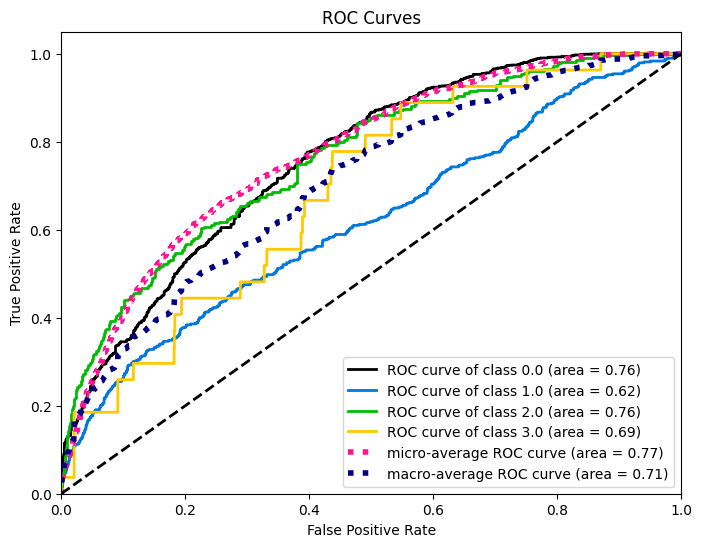

In [20]:
from sklearn.calibration import CalibratedClassifierCV
import scikitplot as skplt


# 2. Model Definition & Calibration
# Wrapping LinearSVC allows it to calculate probabilities
clf = CalibratedClassifierCV(LinearSVC(C=1.0, random_state=42, max_iter=2000), cv=5)
clf.fit(X_train_scaled, y_train_resampled)

# 3. Predictions
y_pred = clf.predict(X_test_scaled)
y_score = clf.predict_proba(X_test_scaled)

# 4. Text Evaluation (Contains Accuracy, F1, Precision, and Recall)
print("Classification Report:\n", classification_report(y_test, y_pred))

# 5. Visual Evaluation
skplt.metrics.plot_roc(y_test, y_score, figsize=(8, 6), title="ROC Curves")
plt.show()

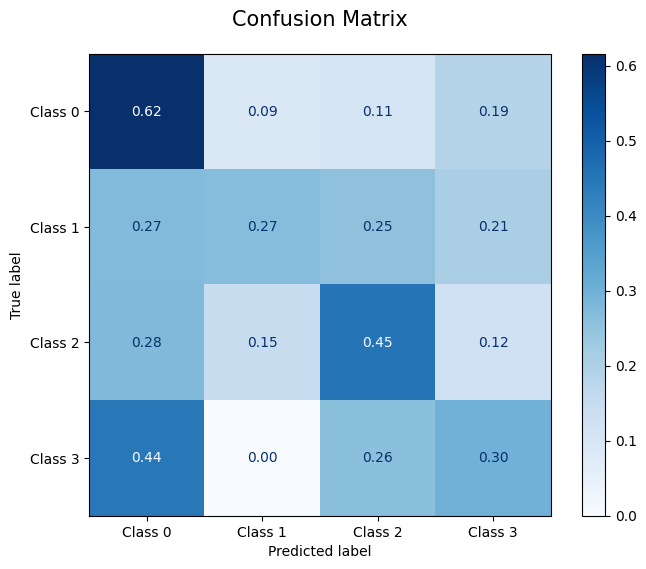

In [21]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

In [18]:
clf = LinearSVC(C=100.0, random_state=42)
clf.fit(X_train_scaled, y_train_resampled)

y_pred = clf.predict(X_test_scaled)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.512608353033885
F1-score [0.69708995 0.29015544 0.34285714 0.03302752]
              precision    recall  f1-score   support

         0.0       0.83      0.60      0.70      1749
         1.0       0.39      0.23      0.29       482
         2.0       0.28      0.45      0.34       280
         3.0       0.02      0.33      0.03        27

    accuracy                           0.51      2538
   macro avg       0.38      0.40      0.34      2538
weighted avg       0.67      0.51      0.57      2538



In [ ]:
clf = LinearSVC(C=0.001, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.9883040935672515
F1-score [0.98412698 0.99074074]
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        64
           1       0.98      1.00      0.99       107

    accuracy                           0.99       171
   macro avg       0.99      0.98      0.99       171
weighted avg       0.99      0.99      0.99       171



/Users/riccardo/anaconda3/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
